# <center> AI - A Guide for Thinking Humans

This experiment aims to compare the performance of a classic **perceptron** and a **neural network** on the MNIST dataset, a benchmark dataset for handwritten digit recognition.

In [1]:
from tensorflow.keras.datasets import mnist

# Load MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Flatten the images and normalize
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test = X_test.reshape(X_test.shape[0], -1) / 255.0

# Print the shapes of the datasets
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 784)
y_train shape: (60000,)
X_test shape: (10000, 784)
y_test shape: (10000,)


Label: 5


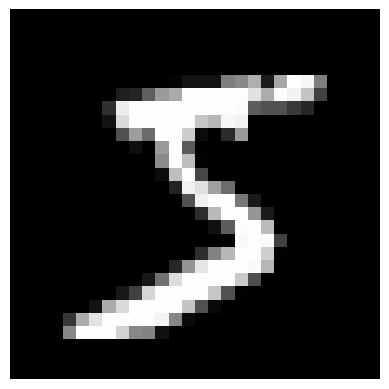

In [13]:
import matplotlib.pyplot as plt
import random

# Take a look
sample_index = random.randint(0, 1000)
sample_image = X_train[sample_index].reshape(28, 28)  # Reshape to 28x28 for visualization
sample_label = y_train[sample_index]

print(f"Label: {sample_label}")
plt.imshow(sample_image, cmap='gray')
plt.axis('off')
plt.show()

---
## Perceptron

In [3]:
import numpy as np

class MultiClassPerceptron:
    def __init__(self, num_inputs, num_classes):
        """
        Initialize a multi-class perceptron with the number of inputs and classes.
        """
        self.num_inputs = num_inputs
        self.num_classes = num_classes
        # Initialize weights for each class (num_classes x (num_inputs + 1) for bias)
        self.weights = np.random.randn(num_classes, num_inputs + 1)

    def make_prediction(self, input_vector):
        """
        Make a prediction for the given input vector.

        Args:
            input_vector (list or np.ndarray): Input features.

        Returns:
            int: Predicted class label.
        """
        # Add the bias term (x0 = 1)
        input_with_bias = np.append(input_vector, 1)
        # Calculate the weighted sums for all classes
        weighted_sums = np.dot(self.weights, input_with_bias)
        # Predict the class with the highest weighted sum
        return np.argmax(weighted_sums)

    def train_model(self, train_data, learning_rate):
        """
        Train the Multi-Class Perceptron using the provided training data.

        Args:
            train_data (list of tuples): Each tuple contains (input_vector, target_label).
            learning_rate (float): Learning rate for weight updates.

        Example of train_data:
            [
                ([0.3, 0.1, ...], 0),
                ([0.0, 0.9, ...], 2),
                ([0.5, 0.7, ...], 1),
                ...
                ([0.0, 1.0, ...], 5)
            ]
        """
        for input_vector, target_label in train_data:
            # Add the bias term (x0 = 1)
            input_with_bias = np.append(input_vector, 1)
            # Make a prediction
            prediction = self.make_prediction(input_vector)

            # If the prediction is incorrect, update weights
            if prediction != target_label:
                # Convert target_label to one-hot encoding
                target_vector = np.zeros(self.num_classes)
                target_vector[target_label] = 1

                # Convert prediction to one-hot encoding
                prediction_vector = np.zeros(self.num_classes)
                prediction_vector[prediction] = 1

                # Update weights for all classes
                self.weights += learning_rate * np.outer(target_vector - prediction_vector, input_with_bias)

In [4]:
# Transform X and y arrays to list of tuples (input_vector, target_label)
def data_pipeline(X, y):
    data = [
        (input_vector.tolist(), int(label))  # Convert input_vector to list and label to int
        for input_vector, label in zip(X, y)
    ]
    return data

train_data = data_pipeline(X_train, y_train)
test_data = data_pipeline(X_test, y_test)

# Initialize the perceptron
perceptron = MultiClassPerceptron(num_inputs=784, num_classes=10)

# Train the Perceptron
for epoch in range(10):  # Train for 10 epochs
    perceptron.train_model(train_data, learning_rate=0.01)

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = []
true_labels = []

# Make predictions and collect true labels
for input_vector, target_label in test_data:
    prediction = perceptron.make_prediction(input_vector)
    predictions.append(prediction)
    true_labels.append(target_label)

# Compute the classification report
class_report = classification_report(true_labels, predictions, target_names=[str(i) for i in range(10)])
print("Classification Report:\n")
print(class_report)

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:\n")
print(conf_matrix)

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.95       980
           1       0.92      0.98      0.95      1135
           2       0.92      0.82      0.86      1032
           3       0.80      0.88      0.84      1010
           4       0.93      0.88      0.91       982
           5       0.77      0.89      0.83       892
           6       0.95      0.90      0.92       958
           7       0.96      0.82      0.88      1028
           8       0.90      0.73      0.81       974
           9       0.80      0.93      0.86      1009

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000

Confusion Matrix:

[[ 955    0    4    3    0   13    1    3    1    0]
 [   1 1116    4    6    0    2    3    1    2    0]
 [  14   30  842   63   15   20   12    5   24    7]
 [   7    5   17  893    4   55    1   

---
## Neural Network

In [6]:
import torch

# Define the Neural Network
class NeuralNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs, units=50):
        super().__init__()
        self.layers = torch.nn.Sequential(
            # hidden layer
            torch.nn.Linear(num_inputs, units),
            torch.nn.ReLU(),
            # output layer
            torch.nn.Linear(units, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits

# Initialize the model
neural_network = NeuralNetwork(num_inputs=784, num_outputs=10)
print(neural_network)

# Check the total number of trainable parameters of this model
num_params = sum(p.numel() for p in neural_network.parameters() if p.requires_grad)
print("# of trainable parameters:", num_params)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=10, bias=True)
  )
)
# of trainable parameters: 39760


In [8]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import OneHotEncoder

# Convert labels to one-hot encoding
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_onehot, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_onehot, dtype=torch.float32)

# Convert PyTorch tensors to TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoader for batching
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
# Let’s now train our neural network...

import torch.nn.functional as F
torch.manual_seed(123)

optimizer = torch.optim.SGD(
    neural_network.parameters(),
    lr=0.01
)

num_epochs = 10
for epoch in range(num_epochs):

    neural_network.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        logits = neural_network(features)
        loss = F.cross_entropy(logits, labels) # Pass the logits directly into the cross_entropy loss function,
                                               # which will apply the softmax function internally

        optimizer.zero_grad() # Sets the gradients from the previous round to 0 to prevent unintended gradient accumulation
        loss.backward()       # Computes the gradients of the loss given the model parameters
        optimizer.step()      # The optimizer uses the gradients to update the model parameters

    ### LOGGING
    print(f"Epoch: {epoch+1}/{num_epochs}"
          f" | Train Loss: {loss:.2f}")

Epoch: 1/10 | Train Loss: 0.59
Epoch: 2/10 | Train Loss: 0.43
Epoch: 3/10 | Train Loss: 0.24
Epoch: 4/10 | Train Loss: 0.22
Epoch: 5/10 | Train Loss: 0.31
Epoch: 6/10 | Train Loss: 0.46
Epoch: 7/10 | Train Loss: 0.19
Epoch: 8/10 | Train Loss: 0.17
Epoch: 9/10 | Train Loss: 0.14
Epoch: 10/10 | Train Loss: 0.14


In [10]:
from sklearn.metrics import classification_report, confusion_matrix

predictions = []
true_labels = []

neural_network.eval()
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = neural_network(inputs)
        predicted = torch.argmax(outputs, dim=1).cpu().numpy()
        actual = torch.argmax(targets, dim=1).cpu().numpy()
        predictions.extend(predicted)
        true_labels.extend(actual)

# Compute the classification report
class_report = classification_report(true_labels, predictions, target_names=[str(i) for i in range(10)])
print("Classification Report:\n")
print(class_report)

# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predictions)
print("Confusion Matrix:\n")
print(conf_matrix)

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.98      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.89      0.92      0.91      1010
           4       0.92      0.94      0.93       982
           5       0.92      0.87      0.90       892
           6       0.94      0.95      0.94       958
           7       0.92      0.93      0.92      1028
           8       0.91      0.89      0.90       974
           9       0.92      0.89      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000

Confusion Matrix:

[[ 962    0    3    2    0    2    7    1    3    0]
 [   0 1109    2    2    0    1    4    2   15    0]
 [  10    7  931   13   13    3   10   13   26    6]
 [   2    0   22  928    0   25    2   